# Clustering Energy Analysis

Thin runner notebook for LRK/xKV clustering comparisons across keys and values, with independent cells for each tensor and clustering axis.

In [75]:
import os
import sys
from pathlib import Path

import pandas as pd
import torch
from scipy.stats import kendalltau, pearsonr, spearmanr


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "utils").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing ./utils")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analysis.utils import display_case_result, load_kv_dump, run_analysis_case

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
kv_dump_path = (
    repo_root
    / "results/kv_dumps/mistralai_Mistral-7B-Instruct-v0.3/niah_multiquery_raw_kv.pt"
)
rope
loaded = load_kv_dump(kv_dump_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

raw_keys = loaded["raw_keys"]
keys = loaded["keys"].to(device)
values = loaded["values"].to(device)
prompt_len = loaded["prompt_len"]
rope_theta = loaded["rope_theta"]

keys.shape, values.shape, prompt_len, rope_theta

TypeError: float() argument must be a string or a real number, not 'NoneType'

In [ ]:
show_detail_tables = False
plot_font_size = 14
show_bound_error_difference = False

if show_bound_error_difference:
    plot_figsize = (12, 6)
else:
    plot_figsize = (12, 4)
combined_plot_figsize = (12, 5)
spectral_plot_figsize = (12, 8)

kmeans_cfg = {
    "n_clusters": 3,
    "kmeans_cluster_size": 512,
    "kmeans_n_iter": 8,
    "kmeans_init": "infllm",
    "kmeans_dtype": torch.float32,
}

decomposition_cfg = {
    "decomposition_method": "svd",
    "rank_selection": "comp_ratio",
    "comp_ratio": 4,
    "energy_threshold": 0.95,
    "decomp_n_iter": 3,
    "decomp_lr": 1e-2,
}

lrk_mode = "per_head"  # "avg_heads" or "per_head"
include_lrk_head_breakdown = False
prefix_end = prompt_len
local_window = 0

xkv_layer_group_size = 4
xkv_num_layers = keys.size(0)


def save_case_figures(figures, case_name):
    plot_names = (
        "lrk_heads",
        "lrk_layers",
        "xkv_groups",
        "lrk_heads_xkv_groups",
        "spectral_tails",
    )
    for figure, plot_name in zip(figures, plot_names, strict=True):
        if figure is None:
            continue
        save_path = f"plots/clustering_bounds_{case_name}_{plot_name}.svg"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        figure.savefig(save_path, bbox_inches="tight", dpi=300)


def print_bound_error_correlations(case_result):
    metric_sets = (
        ("LRK clustered", case_result["lrk_results"], "head", ("layer_idx", "head_idx")),
        ("LRK unclustered", case_result["lrk_results_n1"], "head", ("layer_idx", "head_idx")),
        ("xKV clustered", case_result["xkv_results"], "group", ("group_start_layer", "group_last_layer")),
        ("xKV unclustered", case_result["xkv_results_n1"], "group", ("group_start_layer", "group_last_layer")),
    )

    print("Bound/error correlations:")
    for label, records, metric_scope, group_columns in metric_sets:
        df = pd.DataFrame(records)
        df = df[df["metric_scope"].eq(metric_scope)].copy()
        df["bound"] = df["eta"].clip(lower=0.0).pow(0.5)
        df = (
            df.groupby(list(group_columns), as_index=False)
            .agg(
                bound=("bound", "mean"),
                error=("relative_low_rank_recon_error", "mean"),
            )
        )
        pearson = pearsonr(df["bound"], df["error"]).statistic
        spearman = spearmanr(df["bound"], df["error"]).statistic
        kendall = kendalltau(df["bound"], df["error"]).statistic
        print(
            f"  {label}: Pearson={pearson:.4f}, "
            f"Spearman={spearman:.4f}, Kendall={kendall:.4f}"
        )

## Keys, Row Clustering

In [ ]:
keys_rows = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 4096). Using rank 1.
  warnings.warn(


Bound/error correlations:
  LRK clustered: Pearson=0.8480, Spearman=0.8858, Kendall=0.6998
  LRK unclustered: Pearson=0.7204, Spearman=0.8061, Kendall=0.6074
  xKV clustered: Pearson=0.8527, Spearman=0.8810, Kendall=0.7143
  xKV unclustered: Pearson=0.8339, Spearman=0.7381, Kendall=0.6429


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_rows,256,0.241982,0.236063,0.217116,0.226587,0.039677,0.478992
1,keys_xkv_rows,40,0.248239,0.251723,0.142412,0.143992,0.118377,0.376506
2,keys_lrk_rows_n_clusters_1,256,0.340877,0.331785,0.247783,0.257975,0.089806,0.596154
3,keys_xkv_rows_n_clusters_1,40,0.337959,0.332475,0.109781,0.112854,0.184603,0.509036


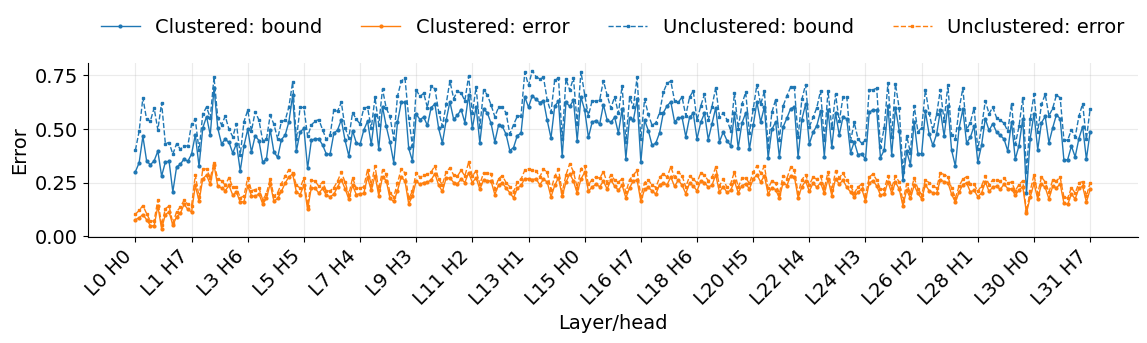

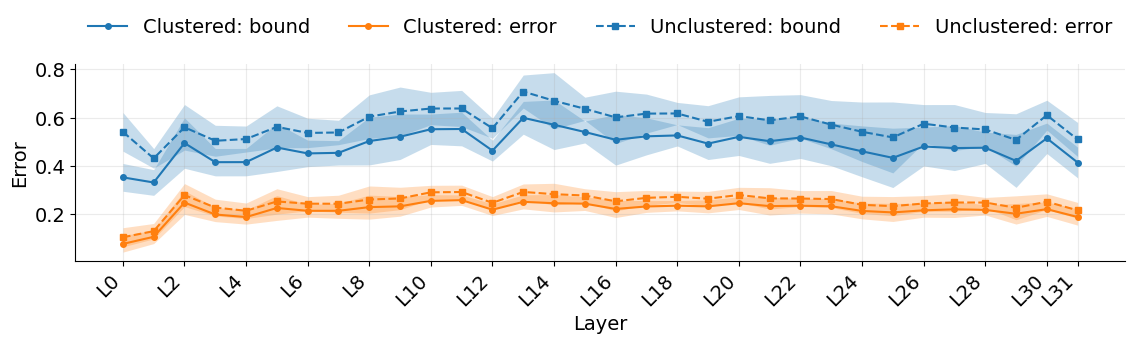

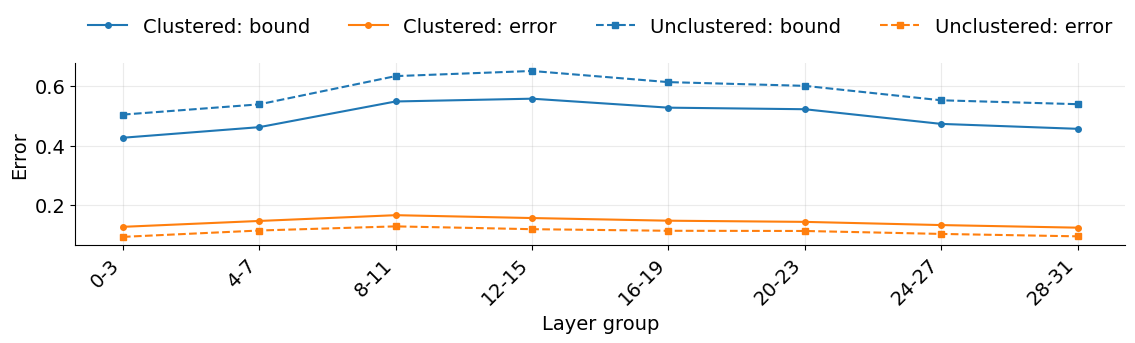

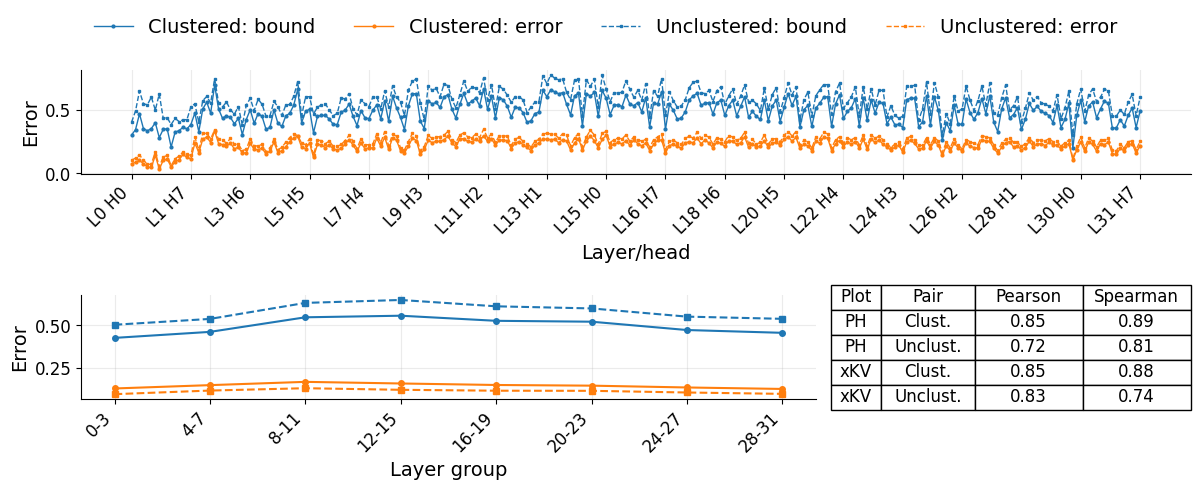

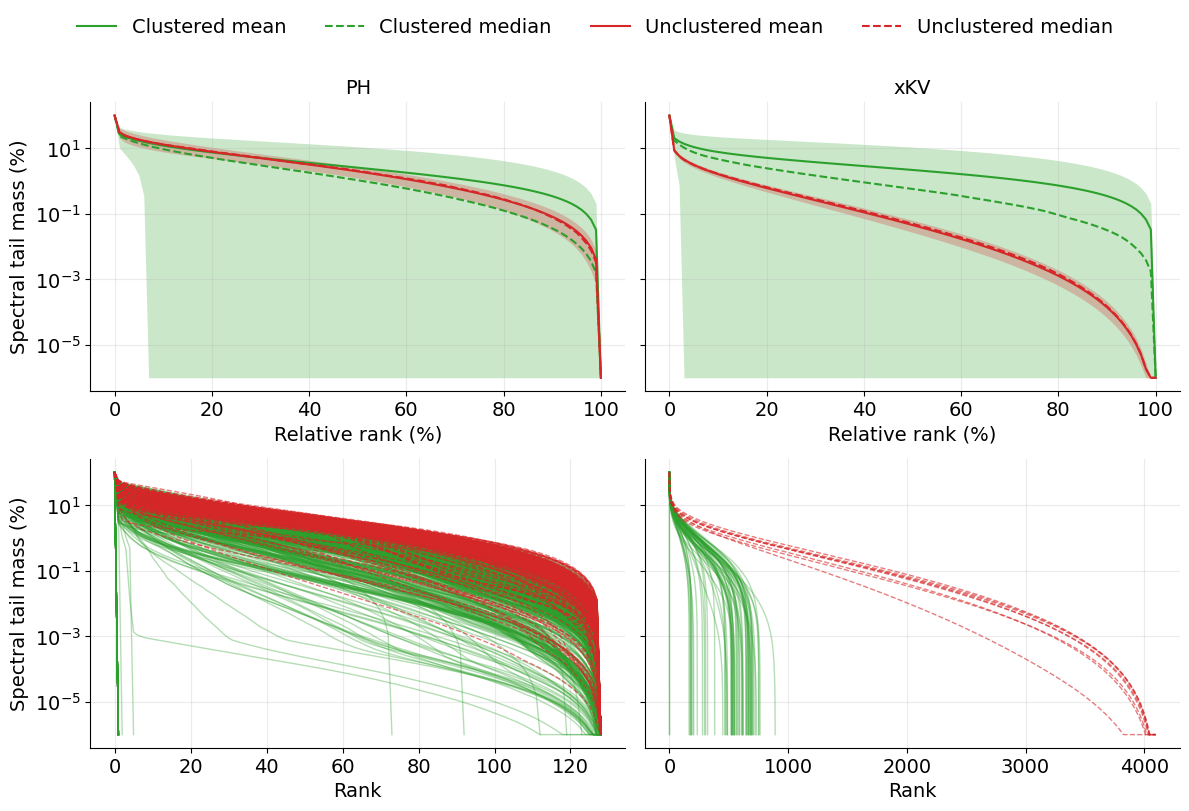

In [ ]:
print_bound_error_correlations(keys_rows)
keys_row_figures = display_case_result(
    keys_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    combined_plot_figsize=combined_plot_figsize,
    spectral_plot_figsize=spectral_plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(keys_row_figures, keys_rows["case_name"])

## Values, Row Clustering

In [ ]:
values_rows = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 4096). Using rank 1.
  warnings.warn(


Bound/error correlations:
  LRK clustered: Pearson=0.8018, Spearman=0.8119, Kendall=0.6242
  LRK unclustered: Pearson=0.7464, Spearman=0.6751, Kendall=0.4925
  xKV clustered: Pearson=0.0048, Spearman=-0.2857, Kendall=-0.2143
  xKV unclustered: Pearson=0.7271, Spearman=0.8333, Kendall=0.7143


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_rows,256,0.763260,0.783192,0.527941,0.536320,0.154589,0.945055
1,values_xkv_rows,40,0.814819,0.828325,0.359430,0.362561,0.474057,0.907317
2,values_lrk_rows_n_clusters_1,256,0.884574,0.918277,0.600722,0.611723,0.251208,0.985507
3,values_xkv_rows_n_clusters_1,40,0.881283,0.908273,0.312427,0.307553,0.547170,0.936585


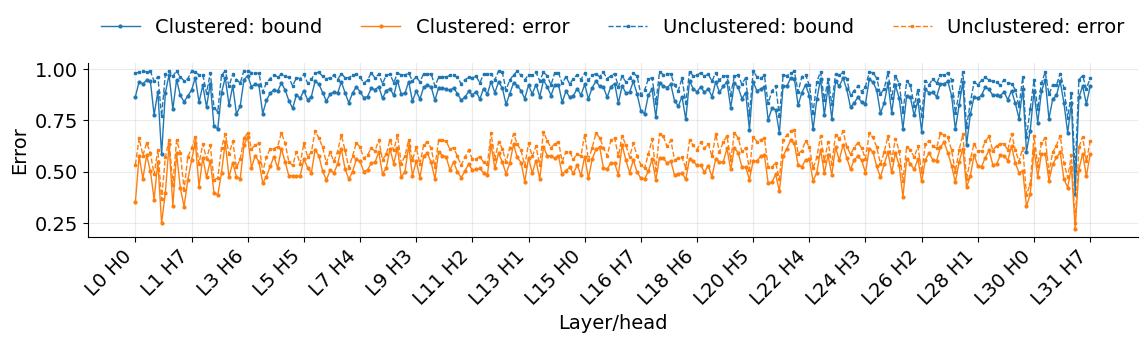

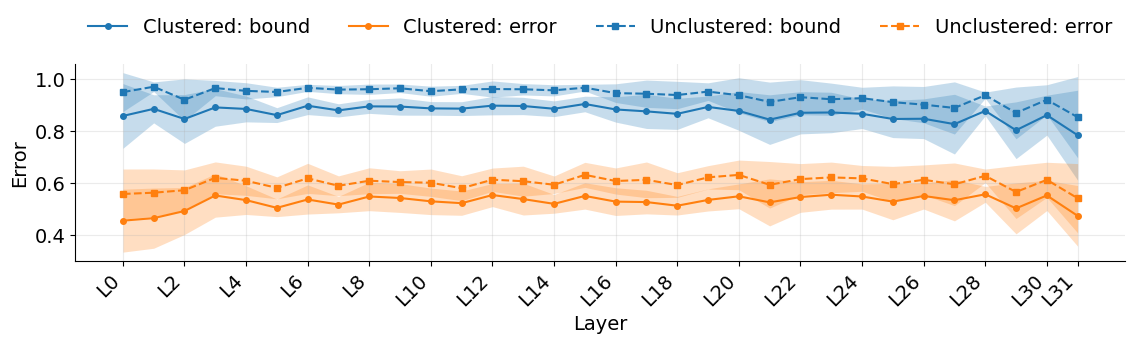

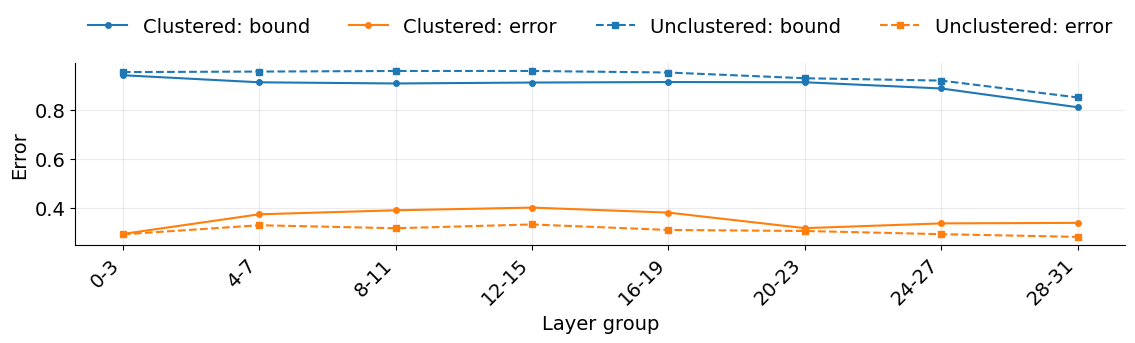

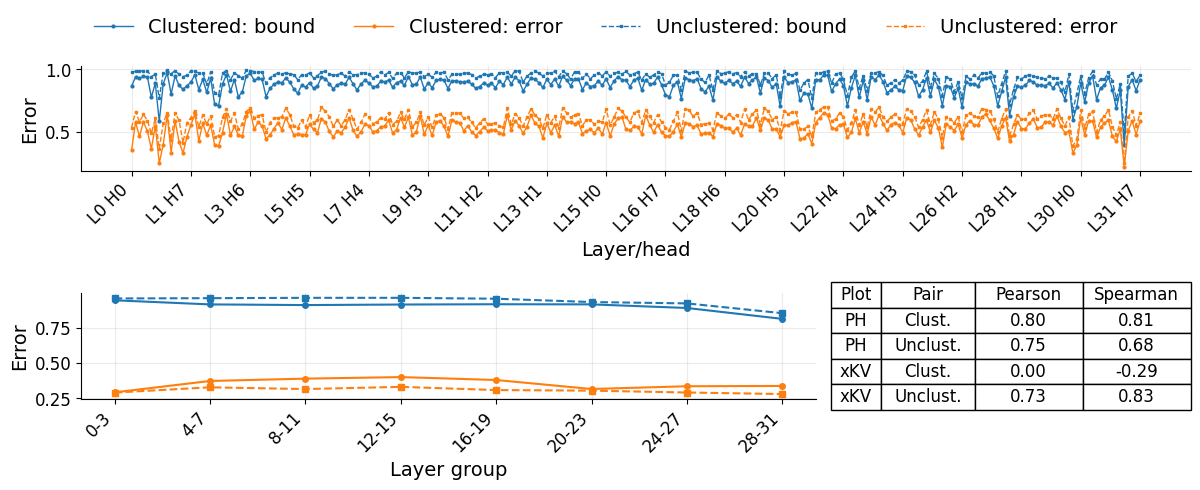

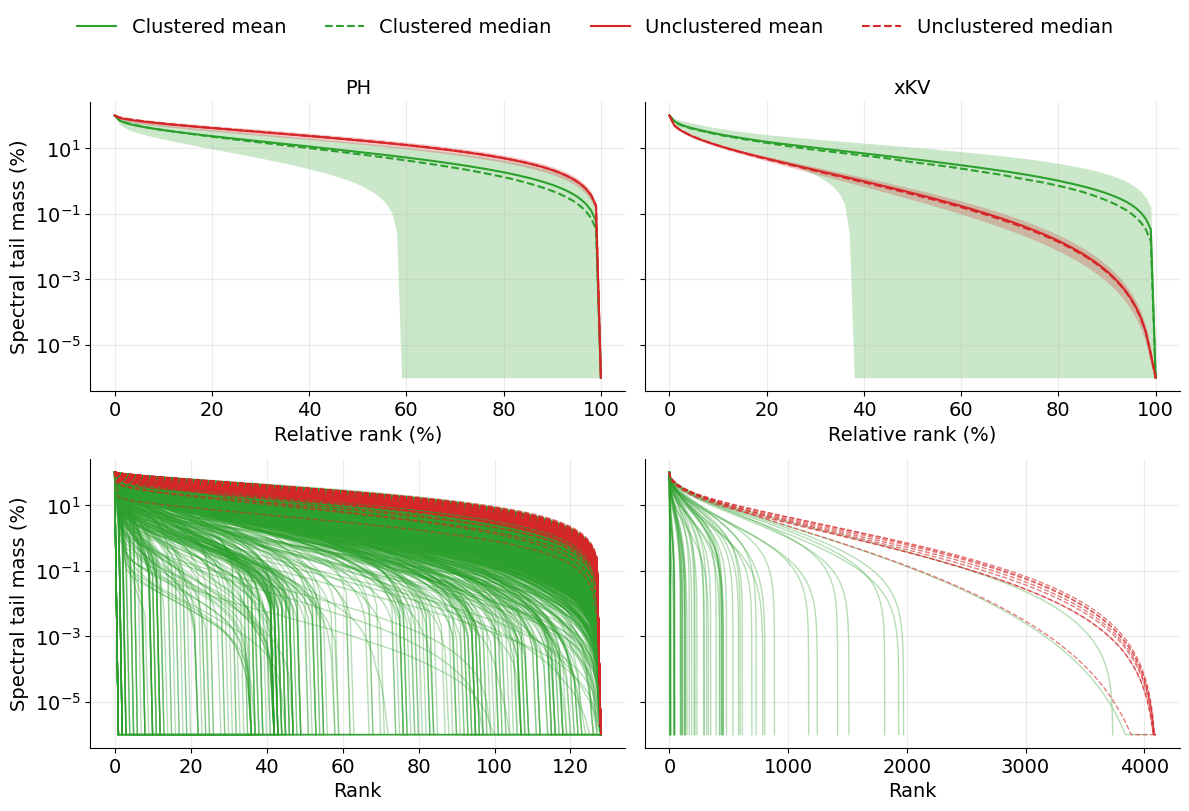

In [ ]:
print_bound_error_correlations(values_rows)
values_row_figures = display_case_result(
    values_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    combined_plot_figsize=combined_plot_figsize,
    spectral_plot_figsize=spectral_plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(values_row_figures, values_rows["case_name"])